In [1]:
import pandas as pd 
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import keras
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_for_preprocessing.csv')
print(df.head())

print ("----------------------")
print(f"Total: \n{df['Author'].value_counts()}")

   Unnamed: 0                                               Text Author
0           0  This study investigates the chemical compositi...     AI
1           1  This study explores the cultural history of oi...     AI
2           2   Isolation of human peripheral blood mononucle...  Human
3           3   Dynamic Bayesian Networks (DBNs) are probabil...  Human
4           4   Within volleyball, performance analysis is em...  Human
----------------------
Total: 
Author
AI       3069
Human    3000
Name: count, dtype: int64


In [3]:
review = []
sentences = list(df['Text'])
for sentence in sentences:
    review.append(sentence)

labels = df['Author']
labels = np.array(list(map(lambda x: 1 if x == 'AI' else 0, labels)))
print(labels[:10])

[1 1 0 0 0 0 0 1 1 1]


In [4]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [5]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9199 - loss: 0.2139 - val_accuracy: 0.9918 - val_loss: 0.0438
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9897 - loss: 0.0525 - val_accuracy: 0.9918 - val_loss: 0.0427
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9895 - loss: 0.0522 - val_accuracy: 0.9918 - val_loss: 0.0427
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9895 - loss: 0.0514 - val_accuracy: 0.9918 - val_loss: 0.0447
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9911 - loss: 0.0375 - val_accuracy: 0.9959 - val_loss: 0.0200


<Axes: >

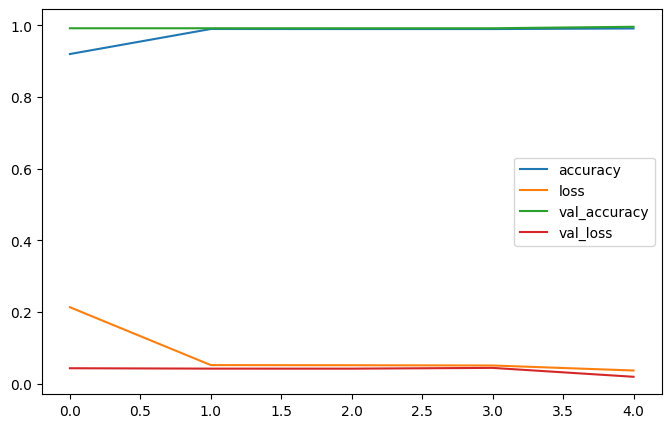

In [6]:
model = keras.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    #keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

callback_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(padded, 
                    train_labels,epochs=5, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[callback_early])
pd.DataFrame(history.history).plot(figsize=(8,5))